# <center> Machine Learning </center>
# <center> Recognizing Iris flowers </center>
# <center> Multinomial Logistic Regression from Scratch </center>

#### **My other projects**:
- Multilayer Perceptron from scratch: https://www.kaggle.com/vitorgamalemos/multilayer-perceptron-from-scratch
- Probability Theory Explanation: https://www.kaggle.com/vitorgamalemos/probability-theory-exploration
- Ensemble using Adaboost (XGB + RF): https://www.kaggle.com/vitorgamalemos/ensemble-adaboost-xgb-rf-in-titanic-survived
- Spam detect using LSTM: https://www.kaggle.com/vitorgamalemos/lstm-sms-spam-detect
- Benford using real example: https://www.kaggle.com/vitorgamalemos/testing-benfords-law-in-a-real-example
- Predict search tendency using Google Trends: https://www.kaggle.com/vitorgamalemos/predict-trends-using-google

# Introduction

<p style="text-align: justify;">This first homework has to do with the classical problem of recognizing different species of Iris flowers relying on the Iris flower dataset. The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by Ronald Fisher in his 1936 paper "The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis".</p>

<div class="container-fluid">
  <div class="row">
      <div class="col-md-2" align='center'>
      </div>
      <div class='col-md-8' align='center'>
           <img src='https://s3.amazonaws.com/assets.datacamp.com/blog_assets/iris-machinelearning.png' />
      </div>
      <div class="col-md-2" align='center'></div>
  </div>
</div>

# Python Libraries 

In the first place, Let's define some libraries to help us in the manipulation the data set, such as `numpy`, `matplotlib`, `seaborn` and `scikit-learn`. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import seaborn as sns

import pandas as pd
from pandas.plotting import scatter_matrix

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris_data = load_iris()

# Dataset Describe

In [2]:
print(iris_data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

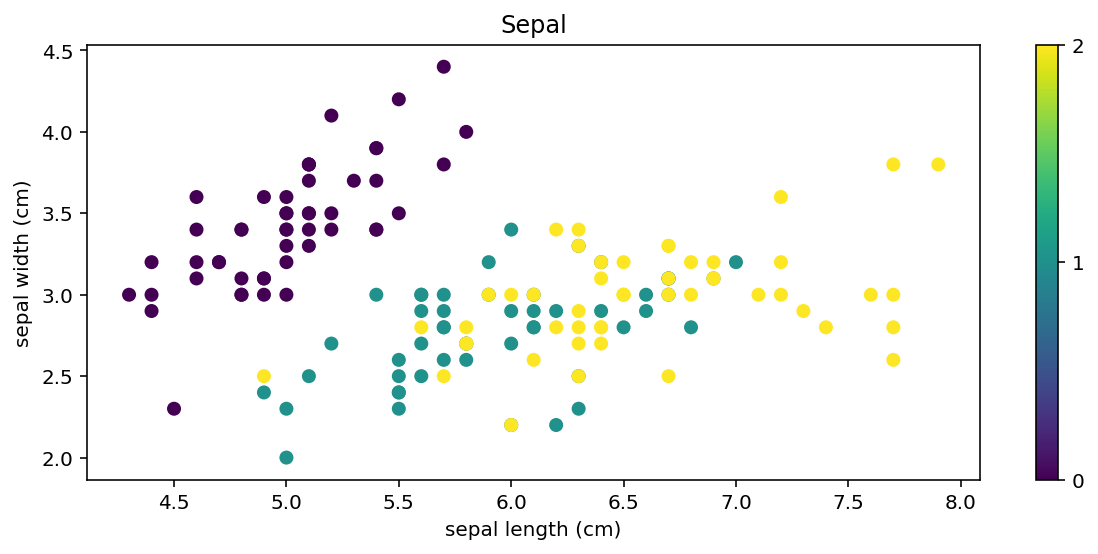

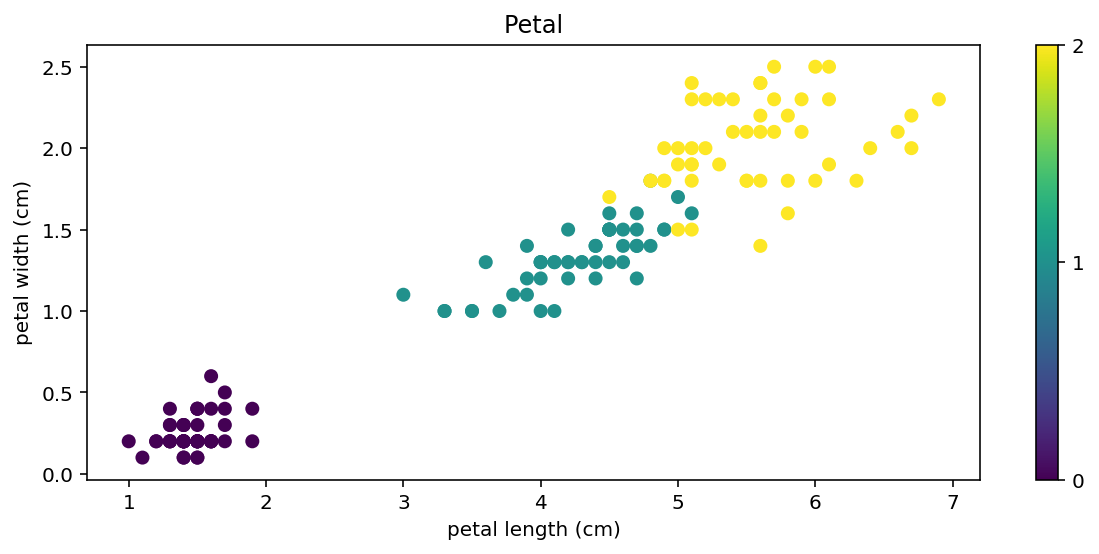

In [3]:
n_samples, n_features = iris_data.data.shape

def show_diagram(x_label,y_label,title):
    plt.figure(figsize=(10,4))
    plt.scatter(iris_data.data[:,x_label], iris_data.data[:,y_label], c=iris_data.target, cmap=cm.viridis)
    plt.xlabel(iris_data.feature_names[x_label]); plt.ylabel(iris_data.feature_names[y_label]); plt.title(title)
    plt.colorbar(ticks=([0, 1, 2]));plt.show();x_label = 2;y_label=3;title='Petal'

show_diagram(0,1,'Sepal')
show_diagram(2,3,'Petal')

# Cross Validation

It is here that we will select our samples to train and test the algorithms. 

#### 80% training and 20% test
<div class="container-fluid">
  <div class="row">
      <div class="col-md-2" align='center'>
      </div>
      <div class='col-md-8' align='center'>
      </div>
      <div class="col-md-2" align='center'></div>
  </div>
</div>

In [4]:
X, y = iris_data.data, iris_data.target
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

(150, 4) (150,)


# Training samples

In [5]:
features_lst = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X_df = pd.DataFrame(X_train, columns=features_lst)
y_df = pd.DataFrame(y_train, columns=['y'])
X_df["y"] = y_df
X_df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,y
0,4.6,3.6,1.0,0.2,0
1,5.7,4.4,1.5,0.4,0
2,6.7,3.1,4.4,1.4,1
3,4.8,3.4,1.6,0.2,0
4,4.4,3.2,1.3,0.2,0
5,6.3,2.5,5.0,1.9,2
6,6.4,3.2,4.5,1.5,1
7,5.2,3.5,1.5,0.2,0
8,5.0,3.6,1.4,0.2,0
9,5.2,4.1,1.5,0.1,0


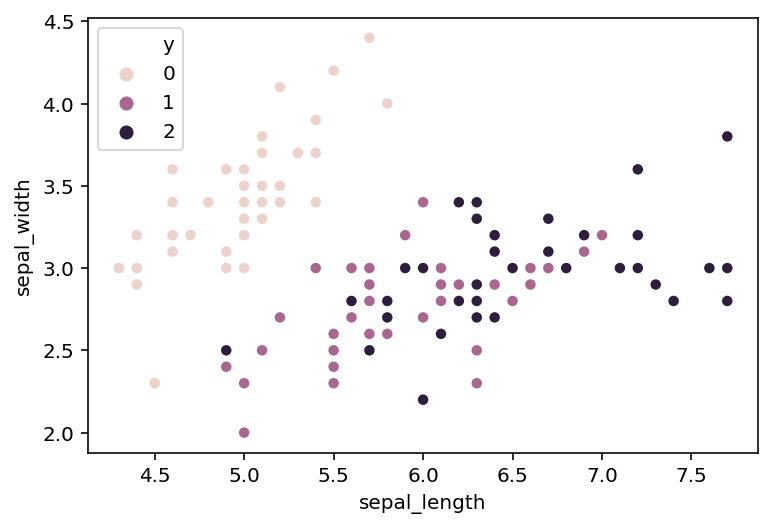

In [6]:
sns.scatterplot(data=X_df, x=features_lst[0], y=features_lst[1], hue="y")
plt.show()

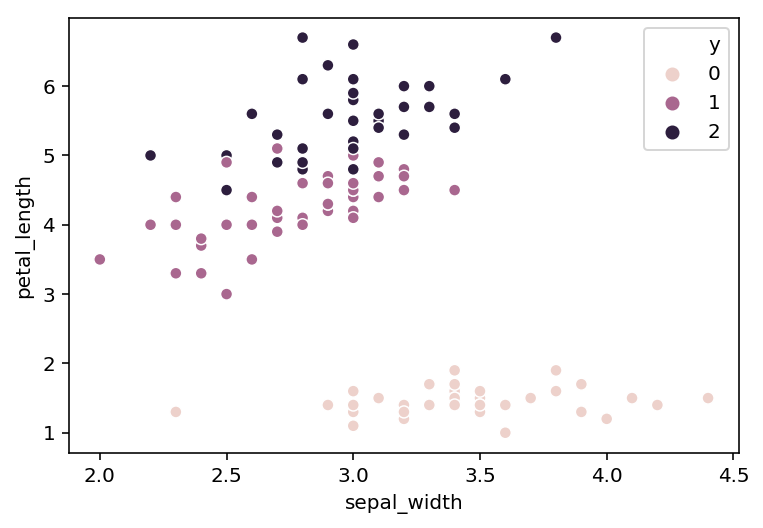

In [7]:
sns.scatterplot(data=X_df, x=features_lst[1], y=features_lst[2], hue="y")
plt.show()

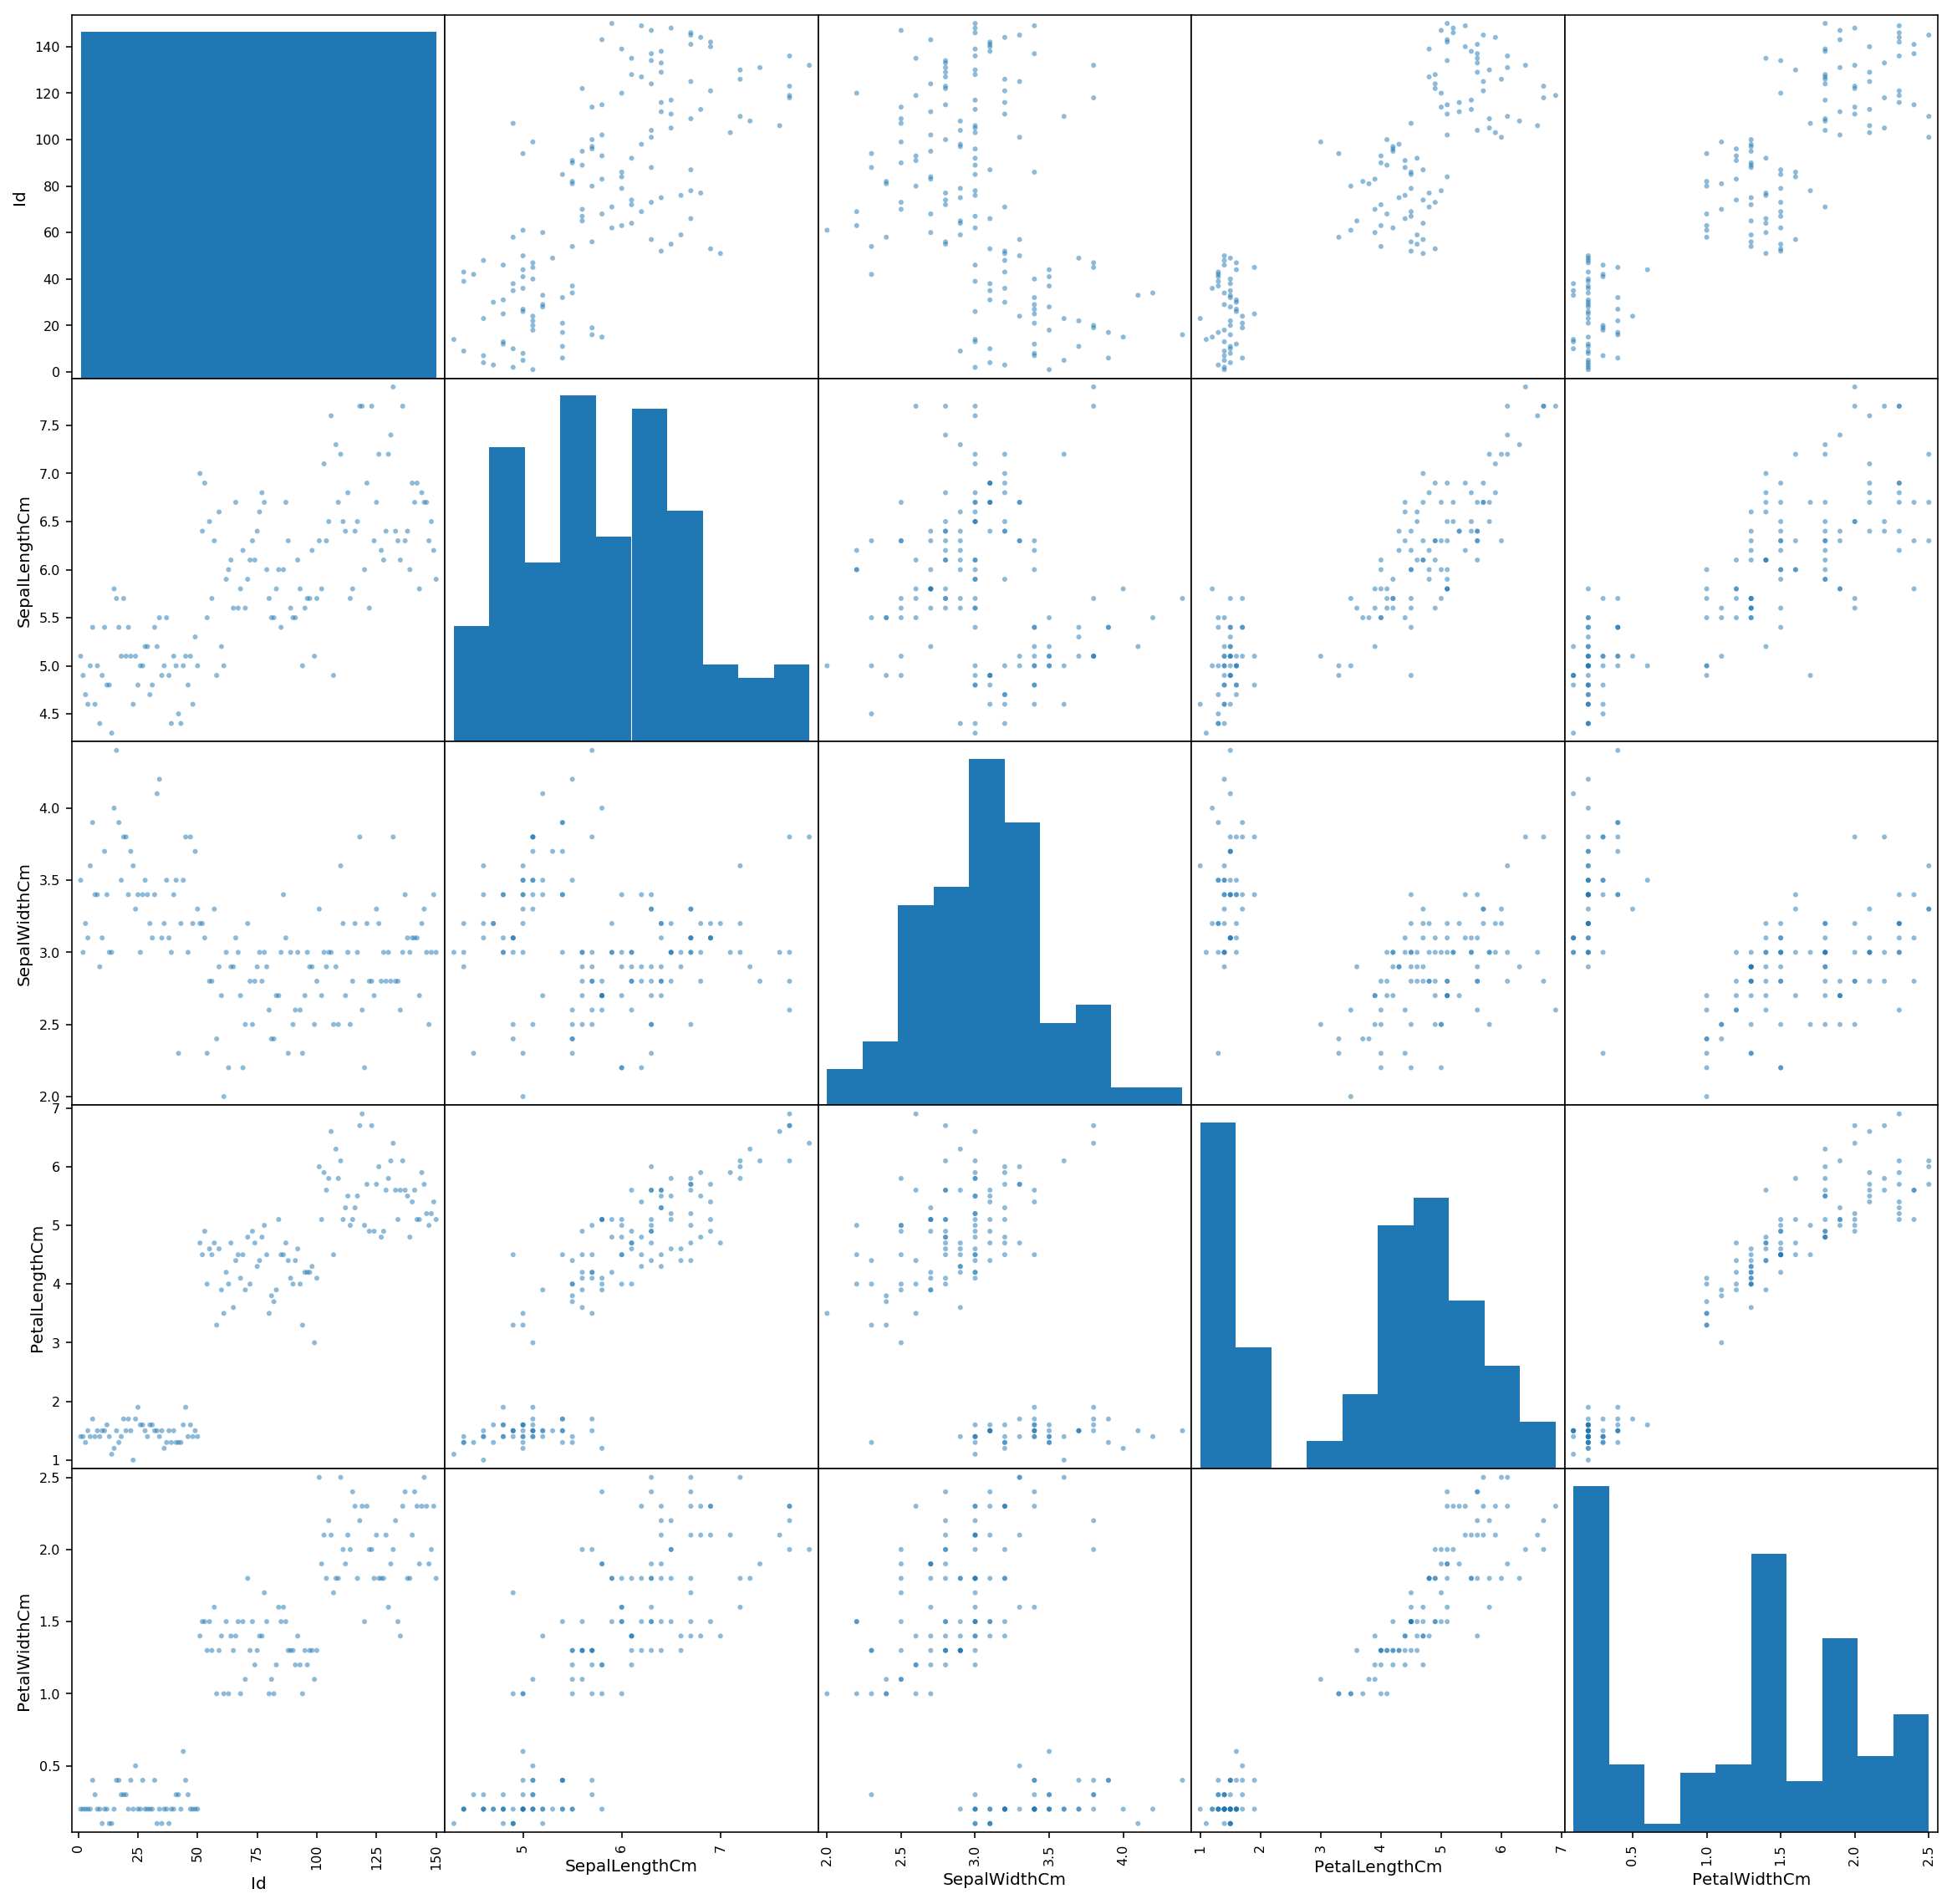

In [8]:
dataset = pd.read_csv('../input/iris/Iris.csv')
scatter_matrix(dataset, alpha=0.5, figsize=(20, 20))
plt.show()

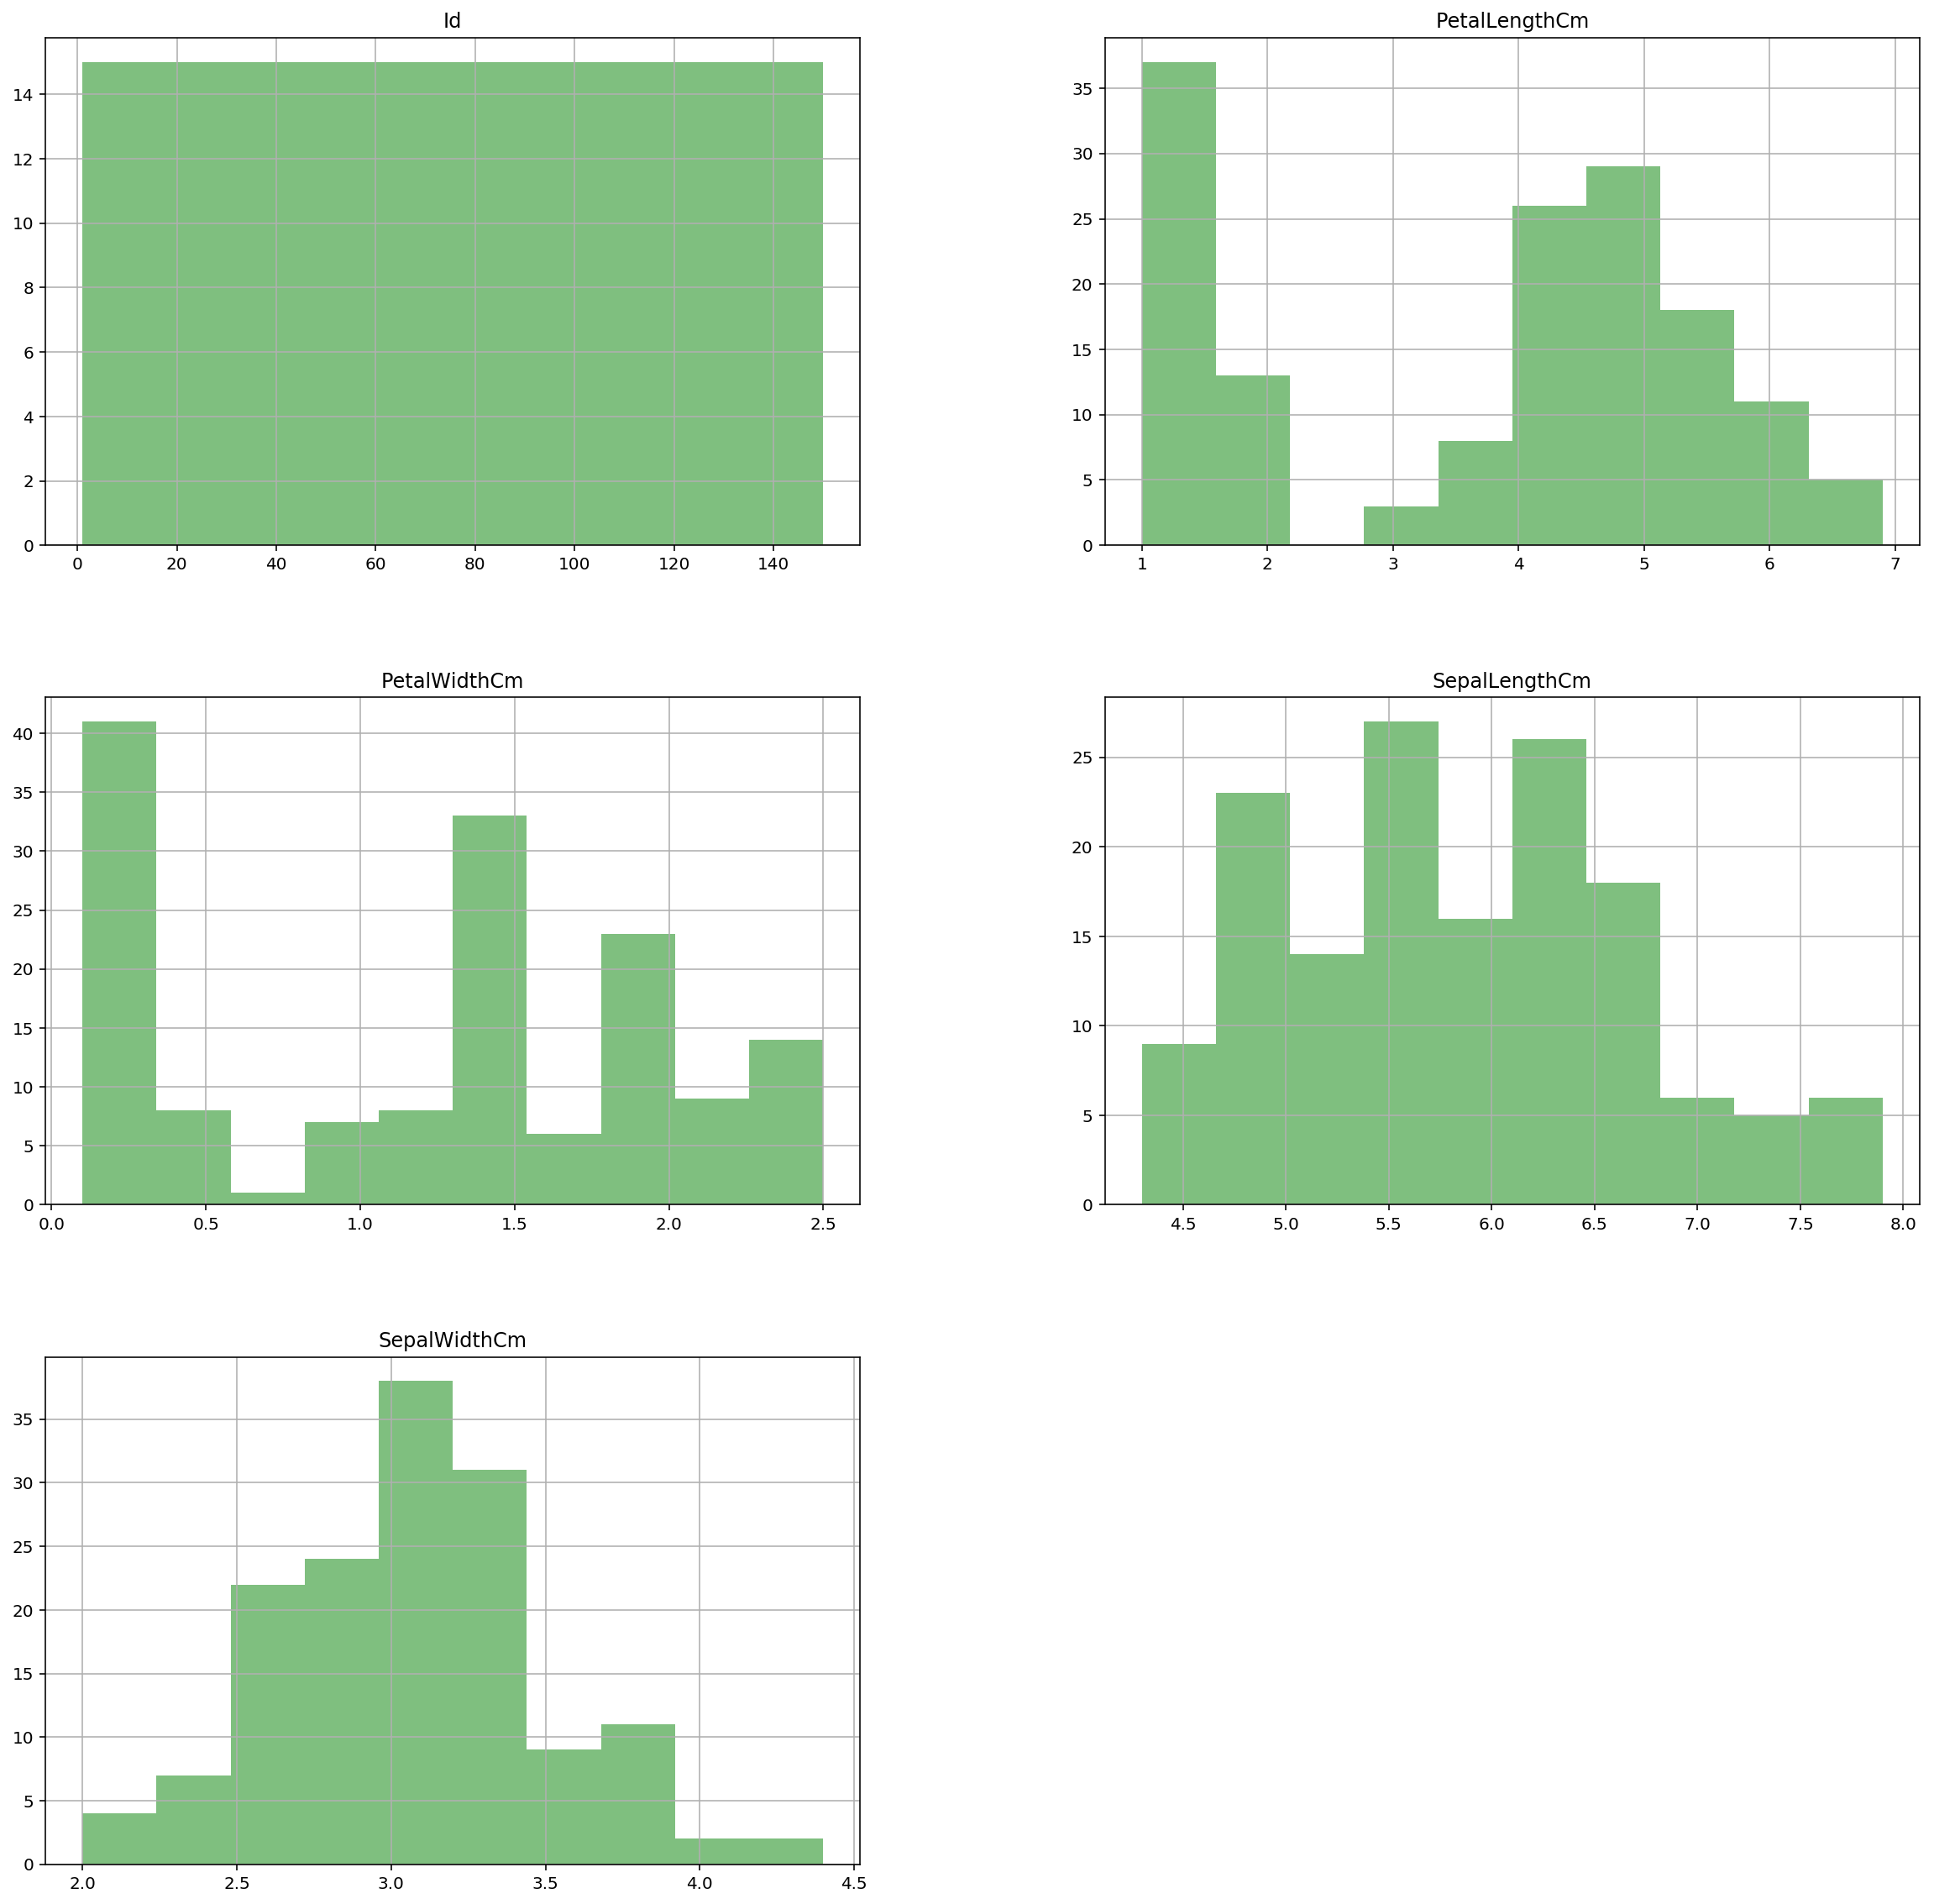

In [9]:
dataset.hist(alpha=0.5, figsize=(20, 20), color='green')
plt.show()

# Multinomial Logistic Regression (Softmax Regression)

<p style="text-align: justify;"> In statistics, multinomial logistic regression is a classification method that generalizes logistic regression to multiclass problems, i.e. with more than two possible discrete outcomes. This is a model used to predict the probabilities of the different possible outcomes of a categorically distributed dependent variable, given a set of independent variables (which may be real-valued, binary-valued, categorical-valued).</p>

<p style="text-align: justify;"> **Multinomial logistic regression ** is known by a variety of other names, including polytomous LR, multiclass LR, softmax regression, multinomial logit, maximum entropy (MaxEnt) classifier, conditional maximum entropy
model.</p>

<p style="text-align: justify;"> ** More information about it: [Softmax Regression](https://en.wikipedia.org/wiki/Multinomial_logistic_regression)** </p> 




## How does Multinomial logistic classifier work?

<img src="https://i2.wp.com/dataaspirant.com/wp-content/uploads/2017/03/Multinomial-Logistic-Classifier-compressor.jpg?resize=690%2C394">
### Step 1. Get Z value
<p style="text-align: justify;"> First, Let's get Z value :
$\text Z = \sum_{i=0}^n w_i x_i\, = w_0 x_0 + w_1 x_1 + w_2 x_2 + ... + w_n x_n $</p>

### Step 2. Cost Function J
<p style="text-align: justify;">  It is function that we need to minimize, which it is calculated as follow:</p>
$$\text J(W) = \frac{1}{n} \sum_{i=0}^n H(T_i, O_i) $$

where, $ H(T_i, O_i)$ or cross-entropy is defined as: 
$$\text H(T_i, O_i) = - \sum_{n} T_i \cdot log(O_i) $$

### Step 3. Softmax Function 
<img src="https://deepnotes.io/public/images/softmax.png">
<p style="text-align: justify;">The softmax function is used in various ** multiclass classification methods **, such as multinomial logistic regression, multiclass linear discriminant analysis, naive Bayes classifiers, and artificial neural networks.</p>
$$ p(y = j | x) = \frac{e^{z.T}}{\sum_{i = 1}^n {e^{z.T}}} $$

### Step 4. Learn using Gradient Descent 

<img src="https://thumbs.gfycat.com/AngryInconsequentialDiplodocus-size_restricted.gif">
<p style="text-align: justify;"> To this work, the implementation Softmax Regression using gradient descent that It is defined as: $ W_{ij} = W_{ij} - \gamma \cdot \nabla_{Wj}J(W) $ </p>Where :
$ \nabla_{Wj} J(W) $ is **cost derivative** defined as:
$$ \nabla_{Wj} J(W) = -\frac{1}{n} \sum_{i = 0}^n (X^{(i)} (T_i - O_i))$$

# Implementation Multinomial logistic (Softmax Regression)


<div class="container-fluid">
  <div class="row">
      <div class="col-md-2" align='center'>
      </div>
      <div class='col-md-8' align='center'>
      </div>
      <div class="col-md-2" align='center'></div>
  </div>
</div>


In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin

class Multinomial_Regression(BaseEstimator, ClassifierMixin): 
    def __init__(self, X, y,params=None):     
        if (params == None):
            self.learningRate = 0.005                  # Learning Rate
            self.max_epoch = 3000                      
        else:
            self.learningRate = params['LearningRate']
            self.max_epoch = params['Epoch'] # Epochs
           
        self.weight = np.array([[0.1,0.2,0.3],
                               [0.1,0.2,0.3],
                               [0.1,0.2,0.3],
                               [0.1,0.2,0.3]])

    def cost_derivate_gradient(self,n,Ti,Oi, X):
        result = -(np.dot(X.T,(Ti - Oi)))/n   
        return result 

    def function_cost_J(self,n,Ti,Oi):
        result = -(np.sum(Ti * np.log(Oi)))/n 
        return result
    
    def one_hot_encoding(self,Y):
        OneHotEncoding = []
        encoding = []
        for i in range(len(Y)):
            if(Y[i] == 0): encoding = np.array([1,0,0]) #Class 1, if y = 0
            elif(Y[i] == 1): encoding = np.array([0,1,0]) #Class 2, if y = 1
            elif(Y[i] == 2): encoding = np.array([0,0,1]) #Class 3, if y = 2

            OneHotEncoding.append(encoding)
        return OneHotEncoding
    
    def accuracy_graphic(self, answer_graph):
        labels = 'Hits', 'Faults'
        sizes = [96.5, 3.3]
        explode = (0, 0.14)
        fig1, ax1 = plt.subplots()
        ax1.pie(answer_graph, explode=explode, colors=['green','red'], labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
        ax1.axis('equal')
        plt.show()

    def softmax(self,z):
        soft = (np.exp(z).T / np.sum(np.exp(z),axis=1)).T 
        return soft
    
    def show_probability(self, arrayProbability):
        
        arrayTotal = []
        ret_value = {
            "prob_c0": [],
            "prob_c1": [],
            "prob_c2": []
        }
        for k in arrayProbability:
            k[0] = "%.3f" % k[0]
            k[1] = "%.3f" % k[1]
            k[2] = "%.3f" % k[2]
            arrayTotal.append(k)
            
        for index, data in enumerate(arrayTotal):
            prob0 = data[0] * 100
            prob1 = data[1] * 100
            prob2 = data[2] * 100

            ret_value["prob_c0"].append(prob0)
            ret_value["prob_c1"].append(prob1)
            ret_value["prob_c2"].append(prob2)
            
        return ret_value
        
    def predict(self, X, y, verbose=True):
        acc_set = acc_vers = acc_virg = 0
        v_resp = []
        n = len(y)
        Z = np.matmul(X, self.weight)
        Oi = self.softmax(Z)
        prevision = np.argmax(Oi,axis=1)
        df_prob = self.show_probability(Oi)
        procent = sum(prevision == y)/n
        if verbose:
            print(" ID-Sample  | Class Classification |  Output |   Hoped output  ")  
            for i in range(len(prevision)):
                if(prevision[i] == 0): print(" id :",i,"          | Iris-Setosa        |  Output:",prevision[i],"   |",y[i])
                elif(prevision[i] == 1): print(" id :",i,"          | Iris-Versicolour   |  Output:",prevision[i],"   |",y[i])
                elif(prevision[i] == 2): print(" id :",i,"          | Iris-Virginica     |  Output:",prevision[i],"   |",y[i])
                
        for i in range(len(prevision)):
            if((prevision[i] == y[i])and(prevision[i] == 0)):acc_set+=1
            elif((prevision[i] == y[i])and(prevision[i] == 1)):acc_vers+=1
            elif((prevision[i] == y[i])and(prevision[i] == 2)):acc_virg+=1
               
        correct = procent * 100
        incorrect = 100 - correct
        v_resp.append(correct)
        v_resp.append(incorrect)
        # self.accuracy_graphic(v_resp)
        return "%.2f"%(correct), acc_set, acc_vers, acc_virg, df_prob

    def show_err_graphic(self,v_epoch,v_error):
        plt.figure(figsize=(9,4))
        plt.plot(v_epoch, v_error, "m-")
        plt.xlabel("Number of Epoch")
        plt.ylabel("Error")
        plt.title("Error Minimization")
        plt.show()

    def fit(self,X,y):
        v_epochs = []
        totalError = []
        epochCount = 0
        n = len(X)
        gradientE = []
        while(epochCount < self.max_epoch):
            Ti = self.one_hot_encoding(y)
            Z = np.matmul(X,self.weight)
            Oi = self.softmax(Z)
            erro = self.function_cost_J(n,Ti,Oi)
            gradient = self.cost_derivate_gradient(n,Ti,Oi,X)
            self.weight = self.weight - self.learningRate * gradient
            if(epochCount % 100 == 0):
                totalError.append(erro)
                gradientE.append(gradient)
                v_epochs.append(epochCount)
                print("Epoch ",epochCount," Total Error:", "%.4f" % erro)
            
            epochCount += 1
        
        self.show_err_graphic(v_epochs,totalError)
        return self

# Optimized Gradient Descent

<img src="https://i0.wp.com/dataaspirant.com/wp-content/uploads/2017/03/Multinomial-Logistic-Regression-model.jpg?resize=690%2C394">


Epoch  0  Total Error: 1.4515
Epoch  100  Total Error: 0.8239
Epoch  200  Total Error: 0.7013
Epoch  300  Total Error: 0.6284
Epoch  400  Total Error: 0.5800
Epoch  500  Total Error: 0.5450
Epoch  600  Total Error: 0.5181
Epoch  700  Total Error: 0.4963
Epoch  800  Total Error: 0.4781
Epoch  900  Total Error: 0.4625
Epoch  1000  Total Error: 0.4487
Epoch  1100  Total Error: 0.4365
Epoch  1200  Total Error: 0.4254
Epoch  1300  Total Error: 0.4152
Epoch  1400  Total Error: 0.4059
Epoch  1500  Total Error: 0.3972
Epoch  1600  Total Error: 0.3891
Epoch  1700  Total Error: 0.3814
Epoch  1800  Total Error: 0.3743
Epoch  1900  Total Error: 0.3675
Epoch  2000  Total Error: 0.3610
Epoch  2100  Total Error: 0.3549
Epoch  2200  Total Error: 0.3491
Epoch  2300  Total Error: 0.3435
Epoch  2400  Total Error: 0.3382
Epoch  2500  Total Error: 0.3331
Epoch  2600  Total Error: 0.3282
Epoch  2700  Total Error: 0.3235
Epoch  2800  Total Error: 0.3190
Epoch  2900  Total Error: 0.3146
Epoch  3000  Total Err

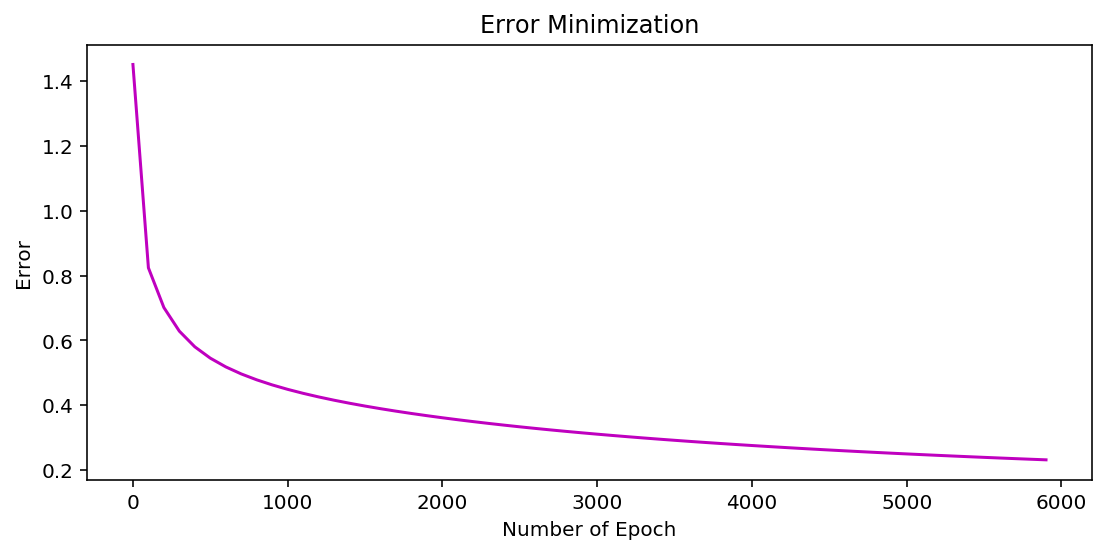

Multinomial_Regression(X=None, params=None, y=None)

In [11]:
arguments = {'Epoch':6000, 'LearningRate':0.005}
SoftmaxRegression = Multinomial_Regression(X_train, y_train, arguments)
SoftmaxRegression.fit(X_train, y_train)

##  Accuracy and precision the Multinomial Regression

In [12]:
acc_test, test_set, test_vers, test_virg, df_prob = SoftmaxRegression.predict(X_test, y_test)
pd.DataFrame(df_prob)

 ID-Sample  | Class Classification |  Output |   Hoped output  
 id : 0           | Iris-Versicolour   |  Output: 1    | 1
 id : 1           | Iris-Setosa        |  Output: 0    | 0
 id : 2           | Iris-Virginica     |  Output: 2    | 2
 id : 3           | Iris-Versicolour   |  Output: 1    | 1
 id : 4           | Iris-Versicolour   |  Output: 1    | 1
 id : 5           | Iris-Setosa        |  Output: 0    | 0
 id : 6           | Iris-Versicolour   |  Output: 1    | 1
 id : 7           | Iris-Virginica     |  Output: 2    | 2
 id : 8           | Iris-Versicolour   |  Output: 1    | 1
 id : 9           | Iris-Versicolour   |  Output: 1    | 1
 id : 10           | Iris-Virginica     |  Output: 2    | 2
 id : 11           | Iris-Setosa        |  Output: 0    | 0
 id : 12           | Iris-Setosa        |  Output: 0    | 0
 id : 13           | Iris-Setosa        |  Output: 0    | 0
 id : 14           | Iris-Setosa        |  Output: 0    | 0
 id : 15           | Iris-Versicolour   |  Out

,prob_c0,prob_c1,prob_c2
0,1.2,69.4,29.5
1,96.6,3.4,0.0
2,0.0,5.3,94.7
3,1.6,63.3,35.1
4,1.1,78.7,20.2
5,95.3,4.7,0.0
6,10.6,78.5,10.9
7,0.3,38.9,60.8
8,0.5,57.4,42.1
9,4.9,81.1,14.0


## Score Iris-Flowers dataset

- Acurracy Iris-Setosa: 100.00 %
- Acurracy Iris-Versicolour: 100.00 %
- Acurracy Iris-Virginica: 100.00 %


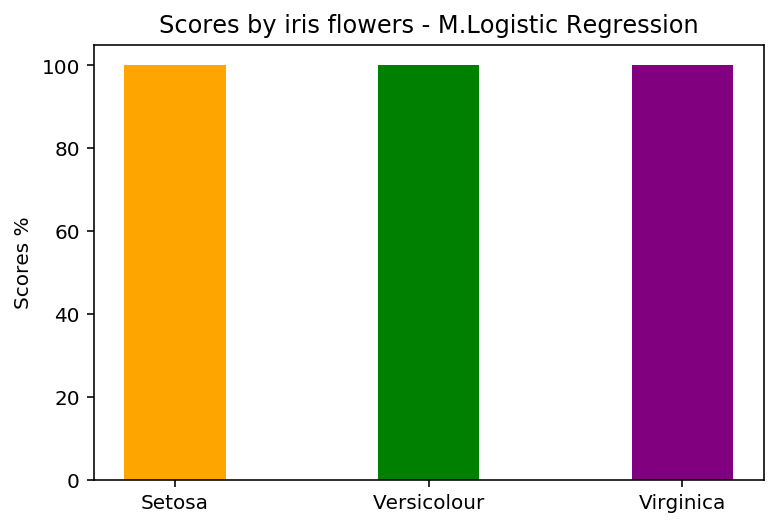

In [13]:
n_set = 0
n_vers = 0
n_virg = 0
for i in range(len(y_test)):
    if(y_test[i] == 0):
        n_set+=1
    elif(y_test[i] == 1):
        n_vers+=1
    elif(y_test[i] == 2):
        n_virg+=1
        
ac_set = (test_set/n_set) * 100
ac_vers = (test_vers/n_vers) * 100
ac_virg = (test_virg/n_virg) * 100

print("- Acurracy Iris-Setosa:","%.2f"%ac_set, "%")
print("- Acurracy Iris-Versicolour:","%.2f"%ac_vers, "%")
print("- Acurracy Iris-Virginica:","%.2f"%ac_virg, "%")

ig, ax = plt.subplots()

plt.bar(2.0, ac_set,color='orange')
plt.bar(4.0, ac_vers,color='g')
plt.bar(6.0, ac_virg,color='purple',label='Iris-Virginica')
plt.ylabel('Scores %')
plt.xticks([2.0, 4.0, 6.0], ["Setosa","Versicolour","Virginica"])
plt.title('Scores by iris flowers - M.Logistic Regression')
plt.show()

## References

**[1]** BROWNLEE, Jason. ** Overfitting and Underfitting With Machine Learning Algorithms(2016)**. Site: [Machine Learning Mastery](https://machinelearningmastery.com/)

